Step 3: Logistic regression

Rain or no rain?

In [67]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_recall_curve, classification_report, 
                            confusion_matrix, roc_auc_score, 
                            precision_recall_curve, auc, f1_score, ConfusionMatrixDisplay)
import shap
import matplotlib.pyplot as plt



Read data

In [83]:
file = '../hourly_columbia_weather.parquet'

# Read parquet into dataframe
df = pd.read_parquet(file)

#print(df.head())

Prepare data, split into x and y

In [ ]:
# defining target (Y) and explanatory variables (X)

# Different variables to exclude for exploratory purposes
exclude_reg = ['wdir', 'coco', 'prcp_flag']
exclude_time = ['day_sin', 'day_cos', 'week_sin', 'week_cos', 'year_sin',
                               'year_cos']
exclude_lag =  [ 'rhum_lag1', 'rhum_lag3', 'rhum_lag6',
       'rhum_lag24', 'pres_lag1', 'pres_lag3', 'pres_lag6', 'pres_lag24',
       'wspd_lag1', 'wspd_lag3', 'wspd_lag6', 'dwpt_lag1', 'dwpt_lag3', 'dwpt_lag6', 'wdir_sin_lag1',
       'wdir_sin_lag3', 'wdir_sin_lag6', 'wdir_cos_lag1', 'wdir_cos_lag3',
       'wdir_cos_lag6', 'prcp_lag1', 'prcp_lag3',
       'prcp_lag6']
exclude_roll =  ['temp_roll3', 'temp_roll6', 'temp_roll12',
       'rhum_roll3', 'rhum_roll6', 'rhum_roll12', 'wspd_roll3', 'wspd_roll6',
       'wspd_roll12', 'prcp_roll3', 'prcp_roll6', 'prcp_roll12', 'dwpt_roll3',
       'dwpt_roll6', 'dwpt_roll12', 'prcp_sum3', 'prcp_sum6', 'prcp_sum12']
exclude_temp = ['temp_roll3', 'temp_roll6', 'temp_roll12', 'temp_lag1', 'temp_lag3',
       'temp_lag6', 'temp_lag24']
exclude_dwpt = ['dwpt','dwpt_lag1', 'dwpt_lag3', 'dwpt_lag6','dwpt_roll3',
       'dwpt_roll6', 'dwpt_roll12']
exclude_lag1 = ['temp_lag1', 'rhum_lag1', 'pres_lag1', 'wspd_lag1', 'dwpt_lag1', 'wdir_sin_lag1', 'wdir_cos_lag1', 'prcp_lag1']
exclude_lag3_roll3 = ['temp_lag3', 'rhum_lag3', 'pres_lag3', 'wspd_lag3', 'dwpt_lag3', 'wdir_sin_lag3', 'wdir_cos_lag3', 'prcp_lag3',
                      'temp_roll3', 'rhum_roll3','wspd_roll3', ]
exclude_current = ['rhum', 'prcp', 'wspd', 'pres','wdir_sin', 'wdir_cos']

# Variable of interest
target_name = 'prcp_flag'

###
# edit exclusion
###
exclude = exclude_reg + [target_name] + ['dwpt'] + exclude_current
X = df.drop(columns=exclude)
Y = df[target_name]
print(X.columns)


Index(['temp', 'day_sin', 'day_cos', 'week_sin', 'week_cos', 'year_sin',
       'year_cos', 'temp_lag1', 'temp_lag3', 'temp_lag6', 'temp_lag24',
       'rhum_lag1', 'rhum_lag3', 'rhum_lag6', 'rhum_lag24', 'pres_lag1',
       'pres_lag3', 'pres_lag6', 'pres_lag24', 'wspd_lag1', 'wspd_lag3',
       'wspd_lag6', 'prcp_lag1', 'prcp_lag3', 'prcp_lag6', 'dwpt_lag1',
       'dwpt_lag3', 'dwpt_lag6', 'wdir_sin_lag1', 'wdir_sin_lag3',
       'wdir_sin_lag6', 'wdir_cos_lag1', 'wdir_cos_lag3', 'wdir_cos_lag6',
       'temp_roll3', 'temp_roll6', 'temp_roll12', 'rhum_roll3', 'rhum_roll6',
       'rhum_roll12', 'wspd_roll3', 'wspd_roll6', 'wspd_roll12', 'prcp_roll3',
       'prcp_roll6', 'prcp_roll12', 'dwpt_roll3', 'dwpt_roll6', 'dwpt_roll12',
       'prcp_sum3', 'prcp_sum6', 'prcp_sum12'],
      dtype='object')


Train/test split

In [71]:
# train/test split
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

Y_train = Y.iloc[:split]
Y_test  = Y.iloc[split:]

# fitting a RF model
#model = LogisticRegression(class_weight="balanced")
model = LogisticRegression(class_weight={0:1, 1:10})

#model = LogisticRegression(class_weight={0: 1, 1: 4})
model.fit(X_train, Y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

c:\Users\Student Account\OneDrive\Junior\CSCE580\ProjectB\env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Choose threshold (minimum probability to predict rain)

In [72]:
precision, recall, thresholds = precision_recall_curve(Y_test, y_prob)

# Compute F1 score for each threshold
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = f1.argmax()
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"Precision: {precision[best_idx]:.3f}")
print(f"Recall:    {recall[best_idx]:.3f}")
print(f"F1-score:  {f1[best_idx]:.3f}")

Best threshold: 0.625
Precision: 0.374
Recall:    0.842
F1-score:  0.518


Use threshold to adjust predictions

In [ ]:
y_pred = (y_prob >= best_threshold).astype(int)

Evaluation

In [ ]:
print(classification_report(Y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.990     0.919     0.953      1658
           1      0.374     0.842     0.518        95

    accuracy                          0.915      1753
   macro avg      0.682     0.881     0.736      1753
weighted avg      0.957     0.915     0.930      1753



In [75]:
cm = confusion_matrix(Y_test, y_pred)
print(cm)

[[1583   75]
 [  42   53]]


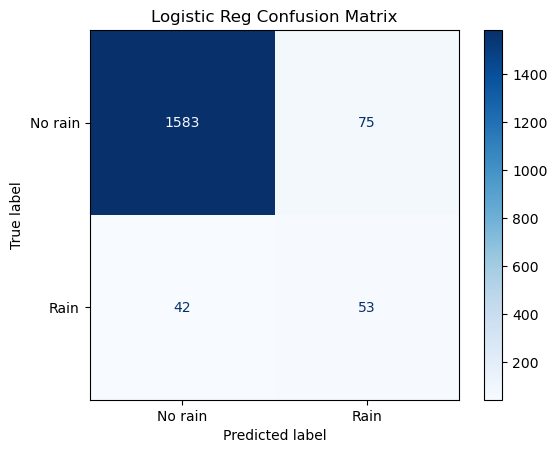

In [76]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No rain", "Rain"]) # Example display labels
disp.plot(cmap=plt.cm.Blues) # Customize colormap if desired
plt.title("Logistic Reg Confusion Matrix")
plt.show()

In [77]:
roc = roc_auc_score(Y_test, y_prob)
print("ROC-AUC:", roc)

ROC-AUC: 0.9402641102152244


In [78]:
precision, recall, _ = precision_recall_curve(Y_test, y_prob)
pr_auc = auc(recall, precision)
print("PR-AUC:", pr_auc)

PR-AUC: 0.5171249807230804
